In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2 as cv
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import math
from pathlib import Path
import os

In [ ]:
data = pd.read_csv('../data/01_dataset.csv')


,image,dx,path
0,ISIC_0000000,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000000.jpg
1,ISIC_0000001,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000001.jpg
2,ISIC_0000002,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000002.jpg
3,ISIC_0000003,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000003.jpg
4,ISIC_0000004,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000004.jpg
...,...,...,...
17392,ISIC_0073241,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073241.jpg
17393,ISIC_0073244,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073244.jpg
17394,ISIC_0073245,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073245.jpg
17395,ISIC_0073249,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073249.jpg


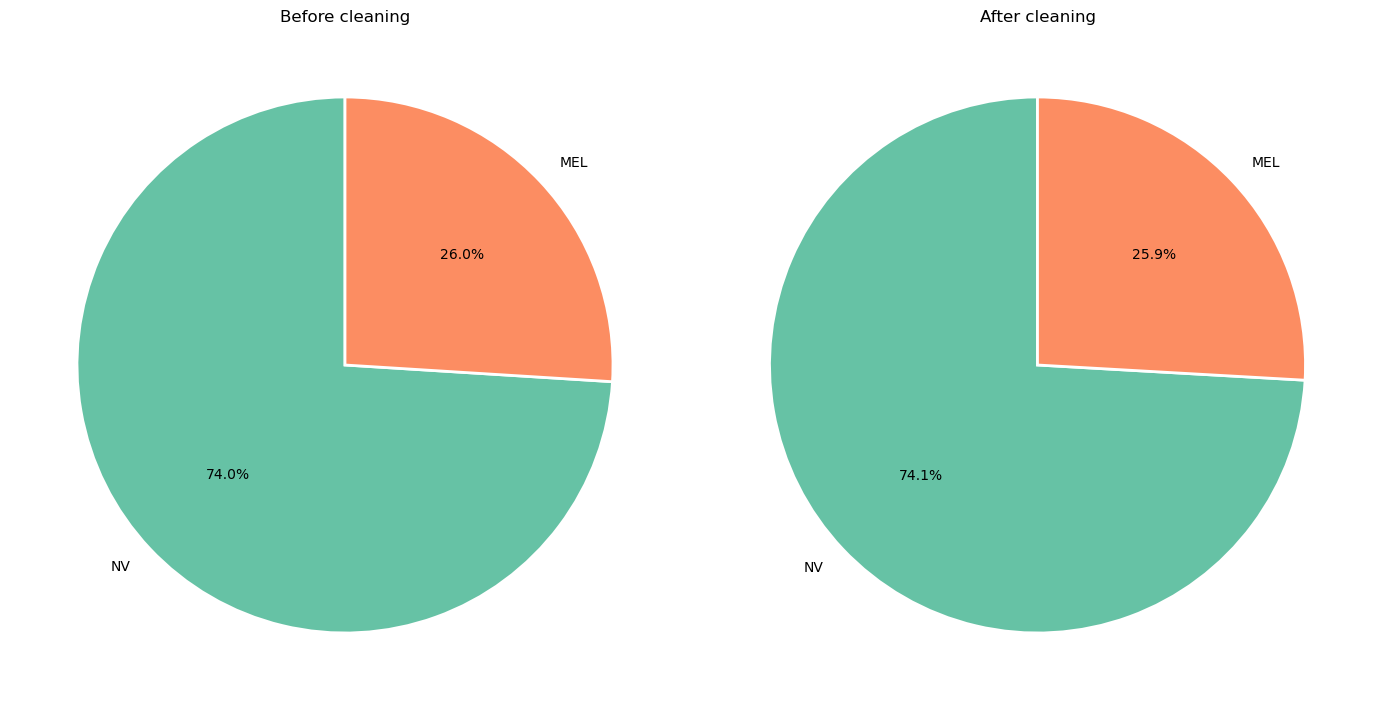

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts_before_clearning = data['dx'].value_counts()
data_filtered = pd.read_csv('../data/02_dataset_w_features.csv')
counts_after_clearning = data_filtered['dx'].value_counts()

colors = sns.color_palette('deep')


colors = sns.color_palette('Set2')

fig, ax = plt.subplots(1, 2, figsize=(14,7))


ax[0].pie(
    counts_before_clearning,
    labels=counts_before_clearning.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax[0].set_title('Before cleaning')


ax[1].pie(
    counts_after_clearning,
    labels=counts_after_clearning.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax[1].set_title('After cleaning')

plt.tight_layout()
plt.show()

,Unnamed: 0,image,dx,path,diameter,compactness,circularity,total_x,total_y,saturation_mean,saturation_std,val_mean,val_std,h0,h1,h2,h3
0,0,ISIC_0000000,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000000.jpg,215.0,15.028339,0.836178,0.735999,0.807093,39.594131,14.867868,96.461916,48.596631,0.601661,0.583699,0.556854,0.539403
1,1,ISIC_0000001,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000001.jpg,93.0,14.465422,0.868718,0.527757,0.834138,100.812754,39.563723,95.153078,40.721247,0.922738,0.918834,0.913123,0.909108
2,2,ISIC_0000002,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000002.jpg,199.0,15.029097,0.836136,0.519741,0.674537,59.161163,29.217215,139.761734,30.506347,0.727695,0.714453,0.695113,0.682957
3,3,ISIC_0000003,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000003.jpg,224.0,15.630267,0.803977,0.737595,0.825801,114.275208,41.837675,143.027448,39.772489,0.682974,0.668970,0.648451,0.635698
4,4,ISIC_0000004,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000004.jpg,154.0,14.947698,0.840689,0.199741,0.552067,105.942549,30.712033,197.129503,22.264115,0.827226,0.819221,0.807538,0.800048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17259,17392,ISIC_0073241,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073241.jpg,201.0,15.633038,0.803834,0.462161,0.581317,83.795711,20.542154,170.779675,12.875236,0.761961,0.738547,0.706159,0.688089
17260,17393,ISIC_0073244,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073244.jpg,243.0,14.954783,0.840291,0.793519,0.796575,55.401616,22.701976,137.606808,28.670436,0.568973,0.540407,0.498542,0.474044
17261,17394,ISIC_0073245,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073245.jpg,186.0,14.806641,0.848698,0.680089,0.794475,111.868606,35.277772,152.391677,23.732672,0.741058,0.728517,0.710674,0.699322
17262,17395,ISIC_0073249,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073249.jpg,244.0,16.619260,0.756133,0.817845,0.594902,47.497358,26.627686,122.928309,37.776683,0.478872,0.441943,0.392358,0.367217


In [4]:
path = '../ISIC/Test/melanoma/ISIC_0000013.jpg'
print(Path(path).stem)

ISIC_0000013


In [2]:
device = torch.device('mps')

In [3]:
model = smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet', in_channels=3, classes=1).to(device)

In [7]:
model.load_state_dict(torch.load('../data/model_weights_skin_segmentation_ham10000.pth', map_location='mps'))

<All keys matched successfully>

In [5]:
def segmentate(image_path, model):
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (256,256))
    img = img.astype('float32') / 255.0
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        output = torch.sigmoid(output).cpu().squeeze().numpy()
        mask = (output > 0.3).astype(np.uint8)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Original image")
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')

    return mask
    

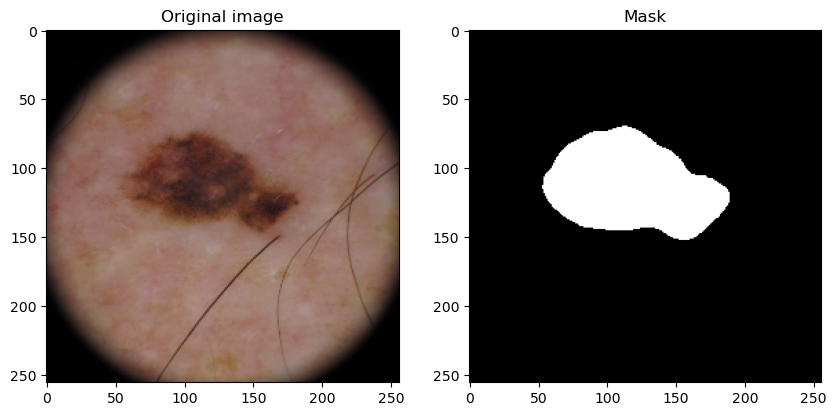

In [10]:
path = '/Users/rafael/Downloads/ISIC_2019/images/MEL/ISIC_0068318.jpg'
mask = segmentate(path, model)

In [409]:
# Extracción de características se regirá por la regla ABCD
# A Asimetría
# B Borde
# C Color
# D diámetro

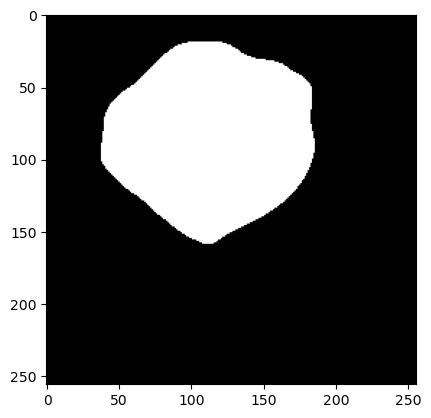

In [410]:
# Apply blur to the mask
kernel = np.ones((15,15), np.uint8)
morph_op = cv.morphologyEx(mask, cv.MORPH_DILATE, kernel, iterations=1)
morph_op = cv.morphologyEx(morph_op, cv.MORPH_ERODE, kernel, iterations=1)

blur_mask = cv.blur(morph_op, (15,15)).astype(np.uint8)
plt.imshow(blur_mask, cmap='gray')

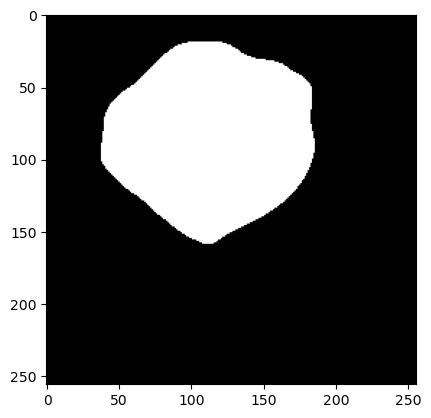

In [411]:
(h,w) = mask.shape[:2]
mask_contours = np.zeros((h,w))
edges = cv.Canny(blur_mask, 100, 200)

contours, hierarchy = cv.findContours(blur_mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

contour_max = max(contours, key=cv.contourArea)

cv.drawContours(mask_contours, [contour_max], -1, 255, -1)
plt.imshow(mask_contours, cmap='gray')

El diametro es: 148


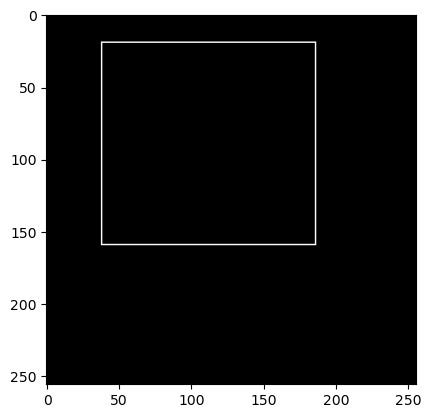

In [412]:
mask_bounding_rectangle = np.zeros((h,w))
x,y,w,h = cv.boundingRect(mask_contours.astype(np.uint8))
cv.rectangle(mask_bounding_rectangle, (x,y), (x+w, y+h), 255)
plt.imshow(mask_bounding_rectangle, cmap='gray')
diameter = max(w,h)
print(f"El diametro es: {diameter}")

In [413]:
# Borde
# Para esto calculamos circularidad
# Necesitamos área y el perimetro anteriormente calculado
perimeter = cv.arcLength(contour_max, True)
area = cv.contourArea(contour_max)

if perimeter > 0:
    circularity = ((4*math.pi*area)/(perimeter*perimeter))


print(circularity)


0.8636784489193874


In [414]:
# image_original = cv.imread(path, cv.IMREAD_COLOR_RGB).astype(np.uint8)
# image_original = cv.resize(image_original, (256,256))

# res = cv.bitwise_and(image_original, image_original, mask=contour_max)

# plt.imshow(image_original)
# plt.imshow(blur_mask, cmap='jet', alpha=0.5)

In [415]:
# Asimetría

mask_flip_y = cv.flip(mask_contours, 1)
mask_flip_x = cv.flip(mask_contours, 0)

symmetry_comparison_y = cv.absdiff(mask_contours, mask_flip_y)
symmetry_comparison_x = cv.absdiff(mask_contours, mask_flip_x)

total_y = np.sum(symmetry_comparison_y)/area
total_x = np.sum(symmetry_comparison_x)/area

print(total_y, total_x)


130.5950368517141 393.78524579079044


In [416]:
image_original

array([[[148, 134, 206],
        [153, 136, 209],
        [158, 142, 213],
        ...,
        [145, 131, 203],
        [137, 125, 197],
        [146, 129, 203]],

       [[143, 132, 202],
        [143, 134, 201],
        [148, 137, 209],
        ...,
        [141, 128, 202],
        [133, 121, 197],
        [139, 127, 203]],

       [[144, 133, 206],
        [139, 132, 205],
        [138, 133, 202],
        ...,
        [136, 123, 199],
        [135, 122, 196],
        [133, 120, 198]],

       ...,

       [[133, 120, 194],
        [131, 120, 193],
        [126, 115, 188],
        ...,
        [121, 120, 184],
        [130, 120, 190],
        [130, 123, 190]],

       [[124, 118, 197],
        [121, 112, 185],
        [122, 114, 185],
        ...,
        [124, 116, 186],
        [127, 119, 184],
        [116, 118, 183]],

       [[128, 123, 198],
        [123, 114, 187],
        [123, 116, 191],
        ...,
        [124, 120, 191],
        [125, 120, 189],
        [118, 117, 185]]